# Q6: Conditional GAN (CGAN) — Text Label to Shape Generator
### Generates shapes (circle, square, triangle) from text labels
**Pipeline:** Text Label → One-Hot Encoding → CGAN → Generated Shape Image → Gradio UI

In [ ]:
# CELL 1: Install Dependencies
!pip install gradio torch torchvision matplotlib numpy Pillow -q
print('All dependencies installed!')

All dependencies installed!


In [ ]:
# CELL 2: Imports & Config
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import gradio as gr
import os
import warnings
warnings.filterwarnings('ignore')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 64
LATENT_DIM  = 100
NUM_CLASSES = 3
BATCH_SIZE  = 64
EPOCHS      = 50
LR          = 0.0002
BETA1       = 0.5

LABELS    = ['circle', 'square', 'triangle']
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}

print(f'Device: {DEVICE}')
print(f'Labels: {LABELS}')
print(f'Config: IMG={IMG_SIZE}, LATENT={LATENT_DIM}, CLASSES={NUM_CLASSES}')

Device: cuda
Labels: ['circle', 'square', 'triangle']
Config: IMG=64, LATENT=100, CLASSES=3


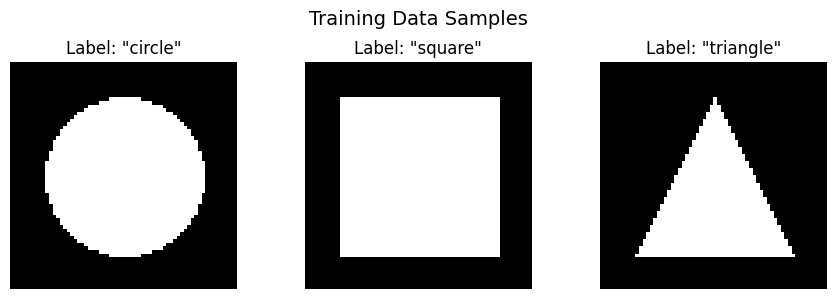

Dataset size: 5000 samples


In [ ]:
# CELL 3: Synthetic Shape Dataset
class ShapeDataset(Dataset):
    def __init__(self, num_samples=5000, img_size=64):
        self.num_samples = num_samples
        self.img_size    = img_size
        self.labels      = [i % NUM_CLASSES for i in range(num_samples)]

    def _draw_shape(self, label_idx):
        img  = Image.new('L', (self.img_size, self.img_size), color=0)
        draw = ImageDraw.Draw(img)
        s    = self.img_size
        pad  = s // 6
        if label_idx == 0:   # circle
            draw.ellipse([pad, pad, s-pad, s-pad], fill=255)
        elif label_idx == 1: # square
            draw.rectangle([pad, pad, s-pad, s-pad], fill=255)
        elif label_idx == 2: # triangle
            pts = [(s//2, pad), (pad, s-pad), (s-pad, s-pad)]
            draw.polygon(pts, fill=255)
        arr = np.array(img, dtype=np.float32) / 127.5 - 1.0
        return torch.tensor(arr).unsqueeze(0)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        label = self.labels[idx]
        image = self._draw_shape(label)
        return image, torch.tensor(label, dtype=torch.long)

dataset = ShapeDataset(num_samples=5000, img_size=IMG_SIZE)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i, label_name in enumerate(LABELS):
    img = dataset._draw_shape(i)
    axes[i].imshow(img.squeeze().numpy(), cmap='gray')
    axes[i].set_title(f'Label: "{label_name}"')
    axes[i].axis('off')
plt.suptitle('Training Data Samples', fontsize=14)
plt.tight_layout()
plt.show()
print(f'Dataset size: {len(dataset)} samples')

In [ ]:
# CELL 4: CGAN Architecture
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, NUM_CLASSES)
        self.fc = nn.Sequential(
            nn.Linear(LATENT_DIM + NUM_CLASSES, 256 * 4 * 4),
            nn.BatchNorm1d(256 * 4 * 4),
            nn.ReLU(True)
        )
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_emb = self.label_emb(labels)
        x = torch.cat([noise, label_emb], dim=1)
        x = self.fc(x)
        x = x.view(-1, 256, 4, 4)
        return self.conv(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, IMG_SIZE * IMG_SIZE)
        self.conv = nn.Sequential(
            nn.Conv2d(2, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, images, labels):
        label_map = self.label_emb(labels)
        label_map = label_map.view(-1, 1, IMG_SIZE, IMG_SIZE)
        x = torch.cat([images, label_map], dim=1)
        x = self.conv(x)
        return self.fc(x)


G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_G     = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D     = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
criterion = nn.BCELoss()

print(f'Generator params  : {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')
print('Models ready!')

Generator params  : 1,123,498
Discriminator params: 706,913
Models ready!


Training for 50 epochs on cuda...
Expected time: ~5-8 min on T4 GPU
Epoch [10/50]  G_loss: 0.7641  D_loss: 0.6797


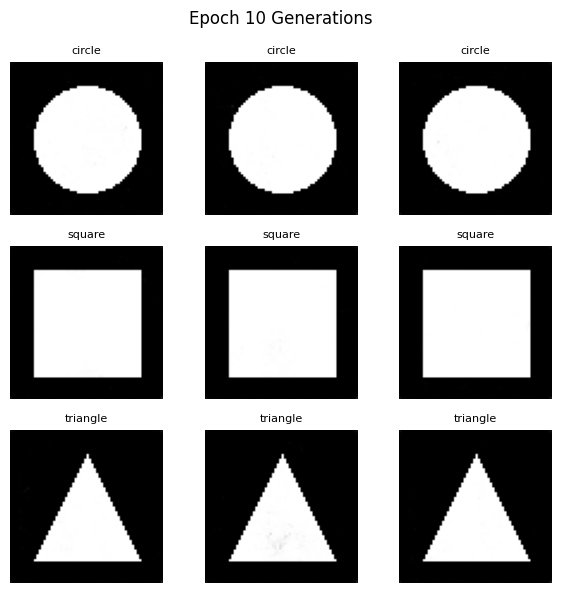

Epoch [20/50]  G_loss: 0.7106  D_loss: 0.6906


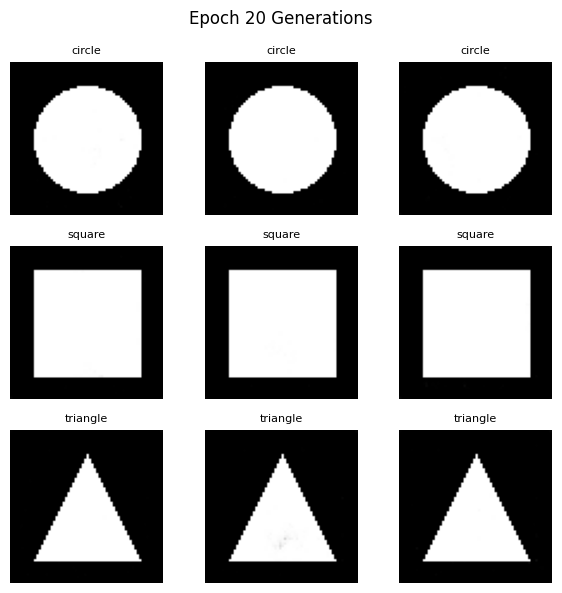

Epoch [30/50]  G_loss: 0.7032  D_loss: 0.6961


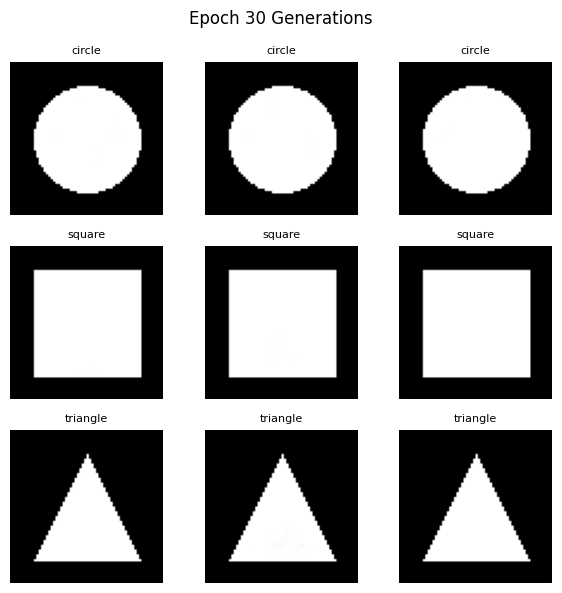

Epoch [40/50]  G_loss: 0.6958  D_loss: 0.6923


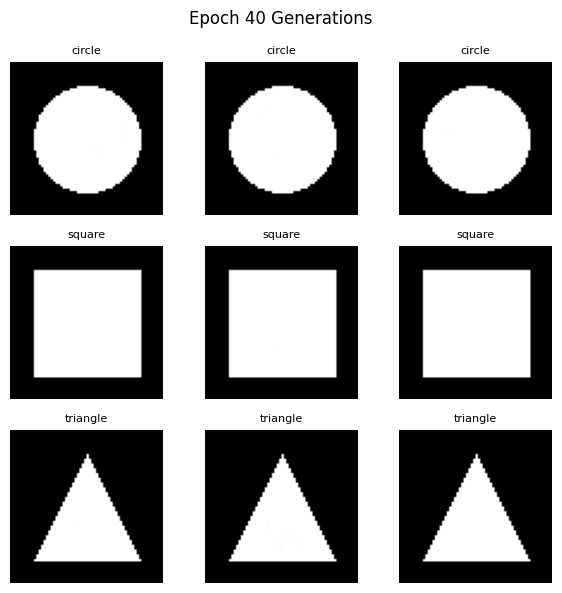

Epoch [50/50]  G_loss: 0.6951  D_loss: 0.6925


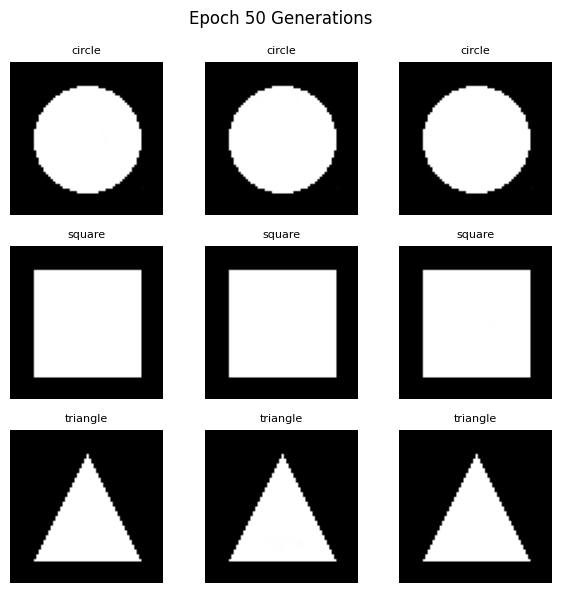

Training Complete!


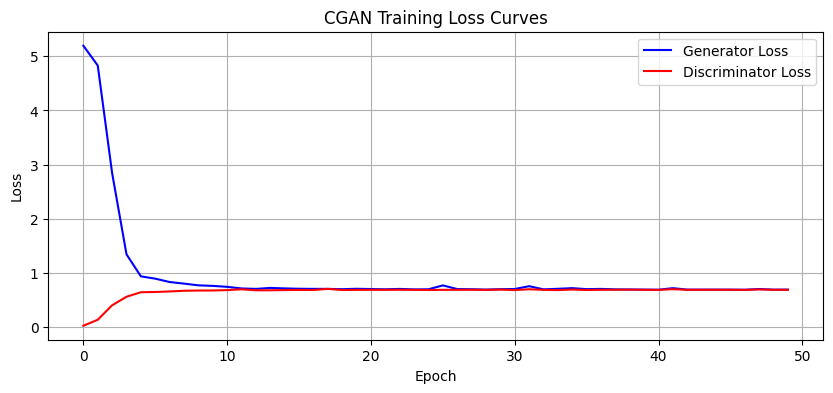

In [ ]:
# CELL 5: Training Loop
G_losses = []
D_losses = []

fixed_noise  = torch.randn(9, LATENT_DIM).to(DEVICE)
fixed_labels = torch.tensor([0,0,0,1,1,1,2,2,2]).to(DEVICE)

print(f'Training for {EPOCHS} epochs on {DEVICE}...')
print('Expected time: ~5-8 min on T4 GPU')
print('='*60)

for epoch in range(EPOCHS):
    epoch_g_loss = 0
    epoch_d_loss = 0

    for real_imgs, labels in loader:
        real_imgs = real_imgs.to(DEVICE)
        labels    = labels.to(DEVICE)
        B         = real_imgs.size(0)

        real_t = torch.ones(B, 1).to(DEVICE)
        fake_t = torch.zeros(B, 1).to(DEVICE)


        opt_D.zero_grad()
        out_real  = D(real_imgs, labels)
        loss_real = criterion(out_real, real_t)

        noise     = torch.randn(B, LATENT_DIM).to(DEVICE)
        fake_imgs = G(noise, labels)
        out_fake  = D(fake_imgs.detach(), labels)
        loss_fake = criterion(out_fake, fake_t)

        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        opt_D.step()


        opt_G.zero_grad()
        noise     = torch.randn(B, LATENT_DIM).to(DEVICE)
        fake_imgs = G(noise, labels)
        out       = D(fake_imgs, labels)
        loss_G    = criterion(out, real_t)
        loss_G.backward()
        opt_G.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()

    avg_g = epoch_g_loss / len(loader)
    avg_d = epoch_d_loss / len(loader)
    G_losses.append(avg_g)
    D_losses.append(avg_d)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}]  G_loss: {avg_g:.4f}  D_loss: {avg_d:.4f}')
        G.eval()
        with torch.no_grad():
            sample_imgs = G(fixed_noise, fixed_labels).cpu()
        G.train()

        fig, axes = plt.subplots(3, 3, figsize=(6, 6))
        for i in range(9):
            axes[i//3][i%3].imshow(sample_imgs[i].squeeze(), cmap='gray')
            axes[i//3][i%3].set_title(LABELS[fixed_labels[i].item()], fontsize=8)
            axes[i//3][i%3].axis('off')
        plt.suptitle(f'Epoch {epoch+1} Generations', fontsize=12)
        plt.tight_layout()
        plt.show()

print('Training Complete!')

plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator Loss', color='blue')
plt.plot(D_losses, label='Discriminator Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CGAN Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# CELL 6: Save Model to Google Drive
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/CGAN_Shapes'
os.makedirs(save_dir, exist_ok=True)
torch.save(G.state_dict(), f'{save_dir}/generator.pth')
torch.save(D.state_dict(), f'{save_dir}/discriminator.pth')
print(f'Models saved to {save_dir}')

Mounted at /content/drive
Models saved to /content/drive/MyDrive/CGAN_Shapes


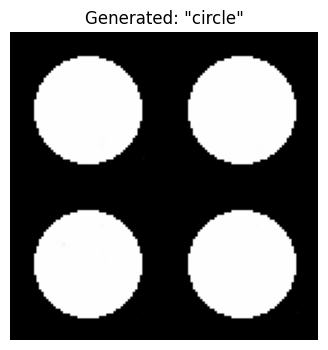

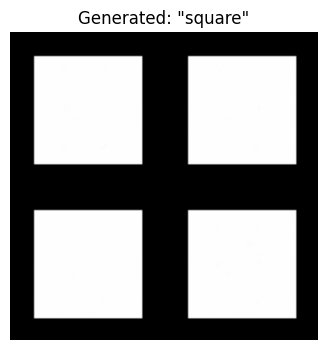

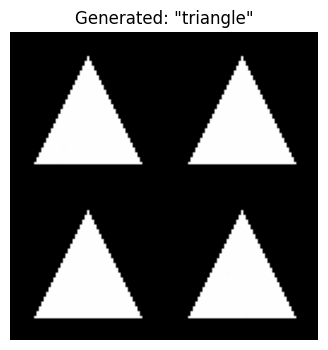

Inference working!


In [ ]:
# CELL 7: Inference Helper
def preprocess_text_label(text):
    text = text.strip().lower()
    aliases = {
        'circle': 0, 'round': 0, 'oval': 0, 'disc': 0,
        'square': 1, 'box': 1, 'rectangle': 1, 'rect': 1,
        'triangle': 2, 'tri': 2, 'pyramid': 2
    }
    if text not in aliases:
        raise ValueError(f"Unknown label: '{text}'. Try: circle, square, triangle")
    return aliases[text]


def generate_shape(text_label, num_samples=4):
    G.eval()
    with torch.no_grad():
        label_idx = preprocess_text_label(text_label)
        noise     = torch.randn(num_samples, LATENT_DIM).to(DEVICE)
        labels    = torch.tensor([label_idx] * num_samples).to(DEVICE)
        fake_imgs = G(noise, labels).cpu()

    imgs_np = ((fake_imgs.squeeze(1).numpy() + 1) / 2 * 255).astype(np.uint8)

    grid_size = int(np.ceil(np.sqrt(num_samples)))
    grid = np.zeros((grid_size * IMG_SIZE, grid_size * IMG_SIZE), dtype=np.uint8)
    for i, img in enumerate(imgs_np):
        r, c = i // grid_size, i % grid_size
        grid[r*IMG_SIZE:(r+1)*IMG_SIZE, c*IMG_SIZE:(c+1)*IMG_SIZE] = img
    return grid



for label in LABELS:
    grid = generate_shape(label, num_samples=4)
    plt.figure(figsize=(4, 4))
    plt.imshow(grid, cmap='gray')
    plt.title(f'Generated: "{label}"')
    plt.axis('off')
    plt.show()
print('Inference working!')

In [ ]:
# CELL 8: Gradio UI
import gradio as gr

def gradio_generate(text_label, num_samples):
    if not text_label.strip():
        return None, 'Please enter a label!'
    try:
        label_idx  = preprocess_text_label(text_label)
        label_name = LABELS[label_idx]
        grid       = generate_shape(text_label, num_samples=int(num_samples))
        pil_img    = Image.fromarray(grid)
        info = f"""Pipeline Results:
Input Text       : "{text_label}"
After Preprocess : "{text_label.strip().lower()}"
Label Index      : {label_idx}
Label Name       : {label_name}
Samples Generated: {num_samples}
Image Size       : {IMG_SIZE}x{IMG_SIZE} per sample
Device Used      : {DEVICE}

How it works:
1. Text label -> lowercase + strip
2. Label index -> Embedding layer (in Generator)
3. Noise vector ({LATENT_DIM}D) + Label embedding concatenated
4. Generator: FC -> ConvTranspose2d blocks -> 64x64 image
"""
        return pil_img, info
    except ValueError as e:
        return None, f'Error: {str(e)}'
    except Exception as e:
        return None, f'Unexpected error: {str(e)}'


with gr.Blocks(title='CGAN Shape Generator', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # CGAN Text-to-Shape Generator
    ### Q6: Conditional GAN generates shapes from text labels
    Type a shape label and click Generate!
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown('### Input')
            text_input = gr.Textbox(
                label='Shape Label',
                placeholder='Type: circle, square, or triangle',
                value='circle'
            )
            num_samples = gr.Slider(minimum=1, maximum=9, value=4, step=1, label='Number of Samples')
            generate_btn = gr.Button('Generate Shape', variant='primary', size='lg')

            gr.Markdown('### Quick Examples')
            with gr.Row():
                gr.Button('Circle').click(lambda: 'circle', outputs=text_input)
                gr.Button('Square').click(lambda: 'square', outputs=text_input)
                gr.Button('Triangle').click(lambda: 'triangle', outputs=text_input)

            gr.Markdown("""
            **Aliases supported:**
            - circle: round, oval, disc
            - square: box, rectangle, rect
            - triangle: tri, pyramid
            """)

        with gr.Column(scale=2):
            gr.Markdown('### Output')
            output_image = gr.Image(label='Generated Shapes', type='pil', height=300)
            output_info  = gr.Textbox(label='Pipeline Info', lines=15, interactive=False)

    generate_btn.click(
        fn=gradio_generate,
        inputs=[text_input, num_samples],
        outputs=[output_image, output_info]
    )

demo.launch(share=True, debug=True)